In [1]:
# imports
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random

from scipy.stats import fisher_exact
from scipy.stats.contingency import odds_ratio

from sklearn import cluster, metrics

from scipy.stats import mannwhitneyu, false_discovery_control, ttest_ind, kstest
from matplotlib.patches import Patch

import cooler 
import cooltools
from matplotlib.colors import LogNorm
import cooltools.lib.plotting
from matplotlib.backends.backend_pdf import PdfPages

from functools import reduce 

import re
#from collections import Counter
import ast 

%cd /home/varshini/uc_analyses/
import utils, matchmaker_functions, loops_txn
%cd /home/varshini/LoopCall_Analysis_Scripts


# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 12})

plt.rcParams["legend.frameon"] = False

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
pval = 0.01
pct1 = 0.1
l2fc = 0.25

mindist=0
dist=100000

diff_thresh=10000

In [3]:
# load clustered MMs from og. data
nametag = "enhancernotpromoternotctcf"
mm = f"/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/nipbl_{nametag}_100kb_merge{diff_thresh/1000}kb_clus.bed"
mm_df = pd.read_csv(mm, sep="\t")
mm_df['quant_diff'] = mm_df['quant_diff'].clip(upper=3)
mm_df['quant'] = mm_df['quant'].clip(upper=3)

mm_df = matchmaker_functions.merged_attrs(mm_df, test_phase='P4', control_phase='P3')
quant_range = np.sort(mm_df['quant'].unique() + 1)


In [4]:
mm_df

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,agg_ss_score_P4,quant,chr_diff,quant_diff,triangle_fc,ss_fc,crosser_fc,ss_crosser_ratio_control,ss_crosser_ratio_test,ratio_fc
10586,chr16,46524005.5,enhancernotpromoternotctcf,0.753388,[],[],[],[2.1167753772824476],['CTCF-CTCF'],"[(46555500.5, 46606500.5)]",...,1.547128,0,chr16,0.0,0.671561,0.687467,NaN,0.0,0.0,NaN
9191,chr13,25753964.0,enhancernotpromoternotctcf,1.286740,[],[],[],[],[],[],...,0.000000,1,chr13,2.0,0.677355,NaN,NaN,NaN,NaN,NaN
13044,chrX,48021514.5,enhancernotpromoternotctcf,0.867108,[1.6623819864957101],['CTCF-Null'],"[(47959500.5, 48025500.5)]",[],[],[],...,0.000000,0,chrX,1.0,0.683579,NaN,0.377245,NaN,NaN,NaN
1219,chr1,224512935.0,enhancernotpromoternotctcf,0.481339,[],[],[],"[4.038764119265054, 1.979791584199039, 2.54539...","['E-P', 'E-P', 'E-E']","[(224433500.5, 224502500.5), (224434500.5, 224...",...,8.950997,0,chr1,0.0,0.685619,1.114205,NaN,0.0,0.0,NaN
10975,chr17,30730977.5,enhancernotpromoternotctcf,0.384133,[],[],[],"[1.2365924589960111, 1.1105226893756404]","['E-Null', 'P-Null']","[(30735500.5, 30757500.5), (30807500.5, 308225...",...,2.302141,0,chr17,0.0,0.688468,0.976406,NaN,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6085,chr7,157851740.5,enhancernotpromoternotctcf,1.036015,[],[],[],[],[],[],...,0.000000,1,chr7,2.0,1.344876,NaN,NaN,NaN,NaN,NaN
10733,chr16,80536427.0,enhancernotpromoternotctcf,0.731346,[],[],[],[],[],[],...,0.000000,0,chr16,0.0,1.361281,NaN,NaN,NaN,NaN,NaN
10933,chr17,21511519.0,enhancernotpromoternotctcf,1.271309,[],[],[],[],[],[],...,0.000000,2,chr17,1.0,1.369391,NaN,NaN,NaN,NaN,NaN
3779,chr4,123555266.5,enhancernotpromoternotctcf,1.055636,[],[],[],[],[],[],...,0.000000,1,chr4,1.0,1.370522,NaN,NaN,NaN,NaN,NaN


In [5]:
mm_df['quant'].unique()

array([0, 1, 2, 3])

In [6]:
# load NIPBL MM scores 

In [7]:
test_phase = 'NIPBL_C3_G1'
control_phase = 'AAVS1_C3_G1'

min_exp = 0.1

In [8]:

def search_dist_for_proms(peaks_df, proms_df, dist):
    peaks_df = peaks_df.copy()
    proms_df = proms_df.copy()
    peaks_df['genes'] = [[] for _ in range(len(peaks_df))]
    peaks_df['l2fc'] = [[] for _ in range(len(peaks_df))]
    for peak_idx, peak_row in peaks_df.iterrows():
        
        peak_chr = peak_row['chr'].split('chr')[1]
        peak_coord = peak_row['coord']
        proms_df['dist'] = abs(proms_df['transcription_start_site'] - peak_coord)
        # Find genes whose TSS is within X of the peak
        nearby_genes = proms_df[
            (proms_df['chromosome_name'] == peak_chr) &
            (abs(proms_df['transcription_start_site'] - peak_coord) <= dist)
        ]

        peaks_df.at[peak_idx, 'genes'] = nearby_genes['external_gene_name'].tolist()
        peaks_df.at[peak_idx, 'min_dist'] = nearby_genes['dist'].min()
        
        if 'log2FoldChange' in proms_df.columns:
            peaks_df.at[peak_idx, 'l2fc'] = nearby_genes['log2FoldChange'].mean()
            
    peaks_df['num_genes'] = peaks_df['genes'].apply(len)
    
    return peaks_df

    
def assign_proms_to_mm(peaks_df, proms_df, min_dist, max_dist):
    peaks = peaks_df.copy()
    proms = proms_df.copy()
    
    # normalize chromosome naming
    peaks["chromosome_name"] = peaks["chr"].str.replace("chr", "", regex=False)

    # output columns
    proms["mm_quant"] = np.nan
    proms["dist"] = np.nan
    proms["triangle_fc"] = np.nan
    proms["mm_peak"] = np.nan

    for chrom, proms_sub in proms.groupby("chromosome_name"):
        peaks_sub = peaks[peaks["chromosome_name"] == chrom]
        if peaks_sub.empty:
            continue

        # sort peaks once
        peaks_sub = peaks_sub.sort_values("coord")
        peak_coords = peaks_sub["coord"].values
        peak_quants = peaks_sub["quant_diff"].values
        tri_scores = peaks_sub["triangle_fc"].values
        # promoter coords
        prom_coords = proms_sub["transcription_start_site"].values

        # find insertion positions
        idxs = np.searchsorted(peak_coords, prom_coords)

        # clip to valid range
        idxs_left = np.clip(idxs - 1, 0, len(peak_coords) - 1)
        idxs_right = np.clip(idxs, 0, len(peak_coords) - 1)

        # compute distances to neighbors
        d_left = np.abs(prom_coords - peak_coords[idxs_left])
        d_right = np.abs(prom_coords - peak_coords[idxs_right])

        # choose nearest
        use_left = d_left <= d_right
        nearest_idxs = np.where(use_left, idxs_left, idxs_right)
        d = np.minimum(d_left, d_right)

        valid = (d <= max_dist) & (d >= min_dist)

        proms.loc[proms_sub.index[valid], "mm_quant"] = peak_quants[nearest_idxs[valid]]
        proms.loc[proms_sub.index[valid], "dist"] = d[valid]
        proms.loc[proms_sub.index[valid], "triangle_fc"] = tri_scores[nearest_idxs[valid]]
        proms.loc[proms_sub.index[valid], "mm_peak"] = peak_coords[nearest_idxs[valid]]

    return proms

In [9]:
os.listdir('/mnt/md0/varshini/Analysis/Blood/complete_analyses/gene_sets_expr/')

['NIPBL_AAVS1_down_lfcShrink.txt',
 'deg_proms_mm3.txt',
 'P3_vs_P1_bulked.tsv',
 'findmarkers_p3.csv',
 'deg_proms_mm0.txt',
 'NIPBL_AAVS1_down_lfcShrink_2.txt',
 'P3_vs_P2_bulked.tsv',
 'rnaseq_tpm_annotated_nfe2.tsv',
 'NFE2_P3_AAVS1_P3_down_lfcShrink_sepExp2.txt',
 'findmarkers_p3_ebm.tsv',
 'findmarkers_ebm.tsv',
 'deg_proms_mm1.txt',
 'NFE2_P3_AAVS1_P3_up_lfcShrink.txt',
 'findmarkers_p3_norm_counts.tsv',
 'NFE2_P3_AAVS1_P3_up_lfcShrink_sepExp2.txt',
 'atac_proms_mm3.txt',
 'NIPBL_AAVS1_down_lfcShrink_sepExp.txt',
 'NFE2_P3_AAVS1_P3_up.txt',
 'rnaseq_tpm_annotated.tsv',
 'promoternotctcf_accessible_all.bed',
 'promoters_eACRs_all.bed',
 'atac_proms_mm1.txt',
 'p31_dge_norm_counts.tsv',
 'P2_vs_P1_bulked.tsv',
 'NFE2_P3_AAVS1_P3_down_lfcShrink.txt',
 'atac_proms_mm0.txt',
 'NIPBL_AAVS1_up_lfcShrink_sepExp.txt',
 'promoternotctcf_eACR.bed',
 'all_bulk_expr.tsv',
 'NFE2_P3_AAVS1_P3_up_lfcShrink_sepExp.txt',
 'deg_proms_mm2.txt',
 'atac_proms_mm2.txt',
 'NFE2_P3_AAVS1_P3_down.txt',
 

In [10]:
tpm_df_all = pd.read_csv('/mnt/md0/varshini/Analysis/Blood/GeneExp/rnaseq_tpm_annotated.tsv', sep='\t', index_col=0)
tpm_df_all['chr'] = tpm_df_all['chromosome_name'].apply(lambda x: f"chr{x}")
tpm_df_all['transcription_start_site'] = tpm_df_all.apply(
    lambda row: row['transcript_start'] if row['strand'] == '+' else row['transcript_end'],
    axis=1
)
tpm_df = tpm_df_all[(tpm_df_all[test_phase]>min_exp)|(tpm_df_all[control_phase]>min_exp)]

genes_of_interest=pd.read_csv('/mnt/md0/varshini/Analysis/Blood/complete_analyses/gene_sets_expr/NIPBL_AAVS1_down_lfcShrink_sepExp.txt', sep='\t', index_col=0)
genes_of_interest = genes_of_interest[genes_of_interest['log2FoldChange']<-0.5]
tpm_df = tpm_df.merge(genes_of_interest, how='inner', left_index=True, right_index=True)

In [13]:
genes_of_interest

,baseMean,log2FoldChange,lfcSE,pvalue,padj
ENSG00000100234,291.671929,-1.928271,0.299386,1.438581e-13,1.021985e-10
ENSG00000117519,665.560166,-1.259498,0.190629,3.162506e-13,1.976658e-10
ENSG00000134817,1250.941441,-1.158069,0.176911,3.273426e-13,1.976658e-10
ENSG00000122694,1000.683392,-1.184895,0.186630,1.261886e-12,6.727902e-10
ENSG00000205213,502.916855,-1.500888,0.253737,1.745779e-11,7.529920e-09
...,...,...,...,...,...
ENSG00000291159,128.743177,-0.514107,0.318678,1.962140e-03,3.681418e-02
ENSG00000235703,27.935998,-0.511777,0.666764,2.274836e-03,4.070103e-02
ENSG00000291250,68.763558,-0.536994,0.408660,2.353099e-03,4.154734e-02
ENSG00000154920,235.432114,-0.510622,0.353252,2.542595e-03,4.415899e-02


In [11]:
genes_of_interest['log2FoldChange'].min()

-3.06370799267929

In [12]:
# process atac in one shot
atac_proms = pd.read_csv("/mnt/md0/varshini/Analysis/Blood/complete_analyses/gene_sets_expr/promoters_accessible_all.bed",
                        sep="\t",
                        names=['chr','start','end','accession','alt','strand']).drop('alt',axis=1).drop_duplicates()

lut = pd.read_csv("/mnt/md0/varshini/Analysis/Adipose/GeneExp/tss_hg38_all_types.tsv",
                 sep="\t").drop_duplicates(subset=['external_gene_name','refseq_id'])

atac_proms_dedup = utils.clean_chroms(atac_proms.merge(lut, how='left', left_on='accession', right_on='refseq_id'))
atac_proms_dedup.drop_duplicates(subset='external_gene_name', inplace=True)
atac_proms_dedup.sort_values(by=['chr','start','end'], inplace=True)

atac_to_mms = assign_proms_to_mm(mm_df, atac_proms_dedup, 0, dist)

/tmp/ipykernel_2201640/2053403066.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  lut = pd.read_csv("/mnt/md0/varshini/Analysis/Adipose/GeneExp/tss_hg38_all_types.tsv",


In [14]:
tpm_df['log2FoldChange'] = np.log2(tpm_df[test_phase]/tpm_df[control_phase])
tpm_df_all_exp = tpm_df_all[(tpm_df_all[test_phase]>min_exp)|(tpm_df_all[control_phase]>min_exp)]
tpm_df_all_exp['log2FoldChange'] = np.log2(tpm_df_all_exp[test_phase]/tpm_df_all_exp[control_phase])

/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
tpm_df

,IKZF1_P3_D1,IKZF1_P2_D1,DMSO_P2_D2,DMSO_P3_D1,AAVS1_P3_D1,AAVS1_C2_G1,IKZF1_P3_D2,STAG2_C3_G2,STAG2_C2_G2,AAVS1_P3_D2,...,transcript_end,transcript_length,strand,chr,transcription_start_site,baseMean,log2FoldChange,lfcSE,pvalue,padj
ENSG00000004777,6.622773,2.328846,2.852778,5.045507,2.708847,5.853810,4.131376,4.544420,4.489039,8.638200,...,35788822,3858,1,chr19,35788822,145.831851,-1.879955,0.403681,1.240481e-03,2.691288e-02
ENSG00000005249,89.569566,131.449318,117.057289,83.873630,83.680819,122.989417,95.945692,128.345296,115.703313,89.796508,...,107161811,3689,1,chr7,107161811,4101.496631,-1.162331,0.172868,4.639476e-08,6.391862e-06
ENSG00000022567,4.267328,7.311688,8.763625,4.809798,4.987550,7.070742,4.958639,8.076499,7.418755,8.107498,...,141228574,3546,-1,chr8,141228574,224.985976,-1.328326,0.277558,2.391121e-04,8.197491e-03
ENSG00000030582,77.447417,86.532625,49.239847,58.923267,47.743502,65.391251,94.309908,71.882590,57.687871,54.526293,...,44353106,2130,1,chr17,44353106,1205.481581,-1.101217,0.205407,2.708384e-05,1.500420e-03
ENSG00000049323,38.231314,25.080124,31.944292,35.969398,22.282336,32.798322,24.941675,38.308534,32.105766,41.303762,...,33399363,5087,1,chr2,33399363,1444.545998,-1.532200,0.188102,1.835151e-11,7.642455e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000284946,1.373394,2.266291,2.276553,2.025019,3.909446,6.275881,2.157843,3.612364,3.132712,5.457557,...,91022566,6683,-1,chr15,91022566,220.450961,-3.280911,0.601873,5.301728e-04,1.469214e-02
ENSG00000291139,3.281279,2.857942,3.853648,3.106121,2.215340,4.816262,1.589601,2.590265,3.238100,7.220911,...,103280984,4536,-1,chr7,103280984,132.039660,-2.450261,0.472445,1.065439e-05,7.109009e-04
ENSG00000291159,2.760568,2.456785,2.197428,2.785128,2.504926,2.092659,2.533918,1.583334,2.061478,5.746062,...,84647478,8986,1,chr15,84647478,128.743177,-1.455143,0.318678,1.962140e-03,3.681418e-02
ENSG00000291250,0.975353,1.345769,1.272764,0.485941,5.268037,9.544152,1.989496,9.143160,5.315397,0.374917,...,31119129,763,-1,chr12,31119129,68.763558,-1.572251,0.408660,2.353099e-03,4.154734e-02


In [16]:
results = []
import scipy
for quant in ([0], [1], [2], [3]):
    mm_thresh = mm_df[(mm_df['quant_diff'].isin(quant))]
    
    genes_to_mms = assign_proms_to_mm(mm_thresh, tpm_df, 0, dist)
    genes_to_mms_thresh = genes_to_mms.dropna(subset='mm_quant')
    genes_to_mms_thresh['ensembl_gene_id'] = genes_to_mms_thresh.index
    
    atac_to_mms_thresh = assign_proms_to_mm(mm_thresh, atac_proms_dedup, 0, dist)
    
    atac_to_mms_notDEG = pd.merge(atac_to_mms_thresh, genes_to_mms_thresh,
                                 on='ensembl_gene_id', how="outer",indicator=True, suffixes=('_atac','_deg'))

    atac_to_mms_notDEG = atac_to_mms_notDEG[atac_to_mms_notDEG['_merge']=='left_only']
    atac_to_mms_notDEG = atac_to_mms_notDEG.dropna(subset='mm_quant_atac')

    tbl_test = [[len(genes_to_mms_thresh), len(atac_to_mms_notDEG)],
       [len(tpm_df) - len(genes_to_mms_thresh), len(atac_to_mms) - len(atac_to_mms_notDEG)]]
    
    print(tbl_test)
    
    print(fisher_exact(tbl_test))
    print(odds_ratio(tbl_test).confidence_interval(confidence_level=0.95))
    print(scipy.stats.contingency.odds_ratio(tbl_test))
    print("\n")

    or_res = odds_ratio(tbl_test)
    ci = or_res.confidence_interval(confidence_level=0.95)

    results.append({
            'quant': quant,
            'OR': or_res.statistic,
            'CI_low': ci.low,
            'CI_high': ci.high
    })

[[45, 4380], [110, 15649]]
SignificanceResult(statistic=1.461612702366127, pvalue=0.0400692845069629)
ConfidenceInterval(low=1.00774228185564, high=2.0891010498887956)
OddsRatioResult(statistic=1.461582388048646)


[[70, 6103], [85, 13926]]
SignificanceResult(statistic=1.8791529720195468, pvalue=0.0001483790142870256)
ConfidenceInterval(low=1.347549969982114, high=2.613059960299604)
OddsRatioResult(statistic=1.879088500265389)


[[77, 5420], [78, 14609]]
SignificanceResult(statistic=2.660831204465891, pvalue=3.036714804831941e-09)
ConfidenceInterval(low=1.9133550052902708, high=3.699229008323737)
OddsRatioResult(statistic=2.6606804615068267)


[[90, 4731], [65, 15298]]
SignificanceResult(statistic=4.477245012438417, pvalue=7.281035828745996e-20)
ConfidenceInterval(low=3.2122429753120896, high=6.2685519522021025)
OddsRatioResult(statistic=4.476822677495158)




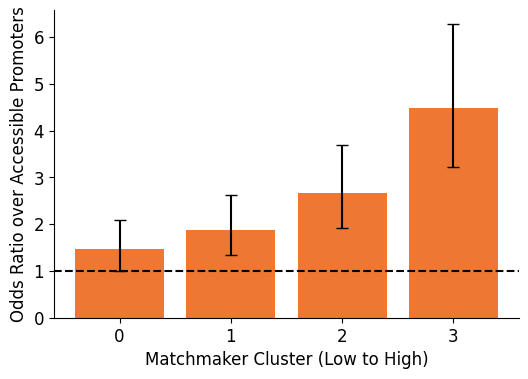

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
results = pd.DataFrame(results)
width = 0.35
x = np.arange(4)

curr = results.sort_values('quant')

y = curr['OR'].values

yerr = np.vstack([
        y - curr['CI_low'].values,
        curr['CI_high'].values - y
    ])

ax.bar(
        x,
        y,
        yerr=yerr,
        capsize=4,
        color="#EE7733"

    )

ax.axhline(1, ls='--', c='k')
ax.set_xticks(x)
ax.set_xticklabels(range(4))
ax.set_xlabel("Matchmaker Cluster (Low to High)")
ax.set_ylabel("Odds Ratio over Accessible Promoters")
ax.legend()
#plt.savefig(os.path.join(savedir, "nipbl_degs_eryTF.svg"))
plt.show()
#plt.savefig(os.path.join(savedir, "nipbl_degs_all_enh.svg"))

In [18]:
def get_odds(test_set, background_set, quant_range, test_title='P3 Marker Genes', comp_title='Background'): # first three are output from the mm finder function
    results = []
    
    for quant in quant_range:
        genes_to_mms_test = test_set[(test_set['mm_quant'].isin(quant))]
        
        
        # get the background which is not in the test set or comparison set
        bg_not_test = pd.merge(background_set, genes_to_mms_test,
                              left_on="ensembl_gene_id",  right_index=True, how="outer", indicator=True, suffixes=('', '_explode'))
        
        bg_not_test = background_set[
            ~background_set["ensembl_gene_id"].isin(
            test_set.index
            )]
            
        #bg_not_test = bg_not_test[bg_not_test['_merge']=='left_only']
        bg_not_test_quant =  bg_not_test[(bg_not_test['mm_quant'].isin(quant))]
       

        tbl_test = [[len(genes_to_mms_test), len(bg_not_test_quant)],
           [len(test_set) - len(genes_to_mms_test), len(bg_not_test) - len(bg_not_test_quant)]]


        print(tbl_test)
        print(fisher_exact(tbl_test))
        print(odds_ratio(tbl_test).confidence_interval(confidence_level=0.95))
        print(scipy.stats.contingency.odds_ratio(tbl_test))
        print("\n")
        
        or_res = odds_ratio(tbl_test)
        ci = or_res.confidence_interval(confidence_level=0.95)

        results.append({
            'quant': quant,
            'group': test_title,
            'OR': or_res.statistic,
            'CI_low': ci.low,
            'CI_high': ci.high
        })
            
    return results

def plot_odds(results, num_quant, test_title, bg_str):

    fig, ax = plt.subplots(figsize=(6, 4))
    results = pd.DataFrame(results)
    width = 0.75

    x = np.arange(num_quant)
    colors = {test_title:"#EE7733"}
    for offset, group in zip([-width, width], [test_title]):

        curr = results[results['group'] == group].sort_values('quant')

        y = curr['OR'].values

        yerr = np.vstack([
            y - curr['CI_low'].values,
            curr['CI_high'].values - y
        ])

        ax.bar(
            x,
            y,
            width=width,
            yerr=yerr,
            capsize=4,
            label=group,
            color=colors[group]

        )

    ax.axhline(1, ls='--', c='k')
    ax.set_xticks(x)
    ax.set_xticklabels(range(num_quant))
    ax.set_xlabel("Matchmaker Cluster (Low to High)")
    ax.set_ylabel(f"Odds Ratio over {bg_str}")
    ax.legend()
    
    return fig


In [19]:
genes_to_mms = assign_proms_to_mm(mm_df, tpm_df, 0, dist)
atac_to_mms = assign_proms_to_mm(mm_df, atac_proms_dedup, 0, dist)

In [20]:
genes_to_mms

,IKZF1_P3_D1,IKZF1_P2_D1,DMSO_P2_D2,DMSO_P3_D1,AAVS1_P3_D1,AAVS1_C2_G1,IKZF1_P3_D2,STAG2_C3_G2,STAG2_C2_G2,AAVS1_P3_D2,...,transcription_start_site,baseMean,log2FoldChange,lfcSE,pvalue,padj,mm_quant,dist,triangle_fc,mm_peak
ENSG00000004777,6.622773,2.328846,2.852778,5.045507,2.708847,5.853810,4.131376,4.544420,4.489039,8.638200,...,35788822,145.831851,-1.879955,0.403681,1.240481e-03,2.691288e-02,2.0,51496.0,0.878124,35737326.0
ENSG00000005249,89.569566,131.449318,117.057289,83.873630,83.680819,122.989417,95.945692,128.345296,115.703313,89.796508,...,107161811,4101.496631,-1.162331,0.172868,4.639476e-08,6.391862e-06,0.0,11451.5,1.015972,107150359.5
ENSG00000022567,4.267328,7.311688,8.763625,4.809798,4.987550,7.070742,4.958639,8.076499,7.418755,8.107498,...,141228574,224.985976,-1.328326,0.277558,2.391121e-04,8.197491e-03,2.0,10466.5,0.946136,141239040.5
ENSG00000030582,77.447417,86.532625,49.239847,58.923267,47.743502,65.391251,94.309908,71.882590,57.687871,54.526293,...,44353106,1205.481581,-1.101217,0.205407,2.708384e-05,1.500420e-03,0.0,21890.5,1.158876,44331215.5
ENSG00000049323,38.231314,25.080124,31.944292,35.969398,22.282336,32.798322,24.941675,38.308534,32.105766,41.303762,...,33399363,1444.545998,-1.532200,0.188102,1.835151e-11,7.642455e-09,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000284946,1.373394,2.266291,2.276553,2.025019,3.909446,6.275881,2.157843,3.612364,3.132712,5.457557,...,91022566,220.450961,-3.280911,0.601873,5.301728e-04,1.469214e-02,2.0,17869.0,0.930968,91004697.0
ENSG00000291139,3.281279,2.857942,3.853648,3.106121,2.215340,4.816262,1.589601,2.590265,3.238100,7.220911,...,103280984,132.039660,-2.450261,0.472445,1.065439e-05,7.109009e-04,3.0,69122.0,1.041752,103350106.0
ENSG00000291159,2.760568,2.456785,2.197428,2.785128,2.504926,2.092659,2.533918,1.583334,2.061478,5.746062,...,84647478,128.743177,-1.455143,0.318678,1.962140e-03,3.681418e-02,2.0,22179.0,1.122840,84625299.0
ENSG00000291250,0.975353,1.345769,1.272764,0.485941,5.268037,9.544152,1.989496,9.143160,5.315397,0.374917,...,31119129,68.763558,-1.572251,0.408660,2.353099e-03,4.154734e-02,NaN,NaN,NaN,NaN


In [21]:
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v2/figure5"

[[18, 2623], [137, 17256]]
SignificanceResult(statistic=0.8643582458376351, pvalue=0.6344203853030188)
ConfidenceInterval(low=0.4965712695332221, high=1.420896663321056)
OddsRatioResult(statistic=0.8643642094940763)


[[42, 3617], [113, 16262]]
SignificanceResult(statistic=1.6710763577110057, pvalue=0.006390816599499506)
ConfidenceInterval(low=1.1414448409264955, high=2.4058829911190065)
OddsRatioResult(statistic=1.6710265993158624)


[[44, 2970], [111, 16909]]
SignificanceResult(statistic=2.25679012345679, pvalue=2.1308954691693288e-05)
ConfidenceInterval(low=1.550564106243957, high=3.234732971977411)
OddsRatioResult(statistic=2.2566714817597906)


[[36, 2315], [119, 17564]]
SignificanceResult(statistic=2.29523930522533, pvalue=4.748147031668639e-05)
ConfidenceInterval(low=1.5310425727928108, high=3.366641713895507)
OddsRatioResult(statistic=2.295111091381567)




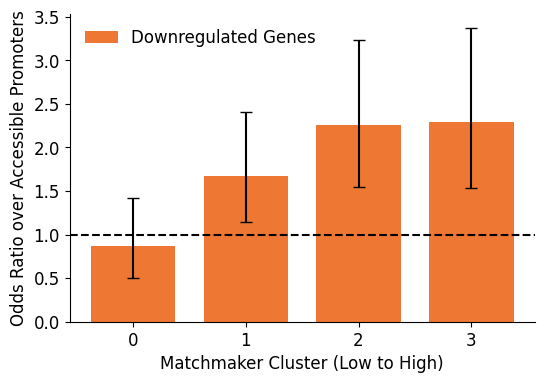

In [22]:
results = get_odds(genes_to_mms, atac_to_mms, ([0],[1], [2],[3]), 
                   test_title='Downregulated Genes',)

fig = plot_odds(results, 4, 'Downregulated Genes', 'Accessible Promoters')
plt.savefig(os.path.join(savedir, "or_no_replacement.svg"))
plt.show()

[[60, 6240], [95, 13639]]
SignificanceResult(statistic=1.3804655870445344, pvalue=0.05590205373524257)
ConfidenceInterval(low=0.9806932523958249, high=1.9300521620513769)
OddsRatioResult(statistic=1.3804421861157017)


[[80, 5285], [75, 14594]]
SignificanceResult(statistic=2.9454935351624094, pvalue=5.3882132392838925e-11)
ConfidenceInterval(low=2.1187695735332235, high=4.098017354769336)
OddsRatioResult(statistic=2.94530542277685)




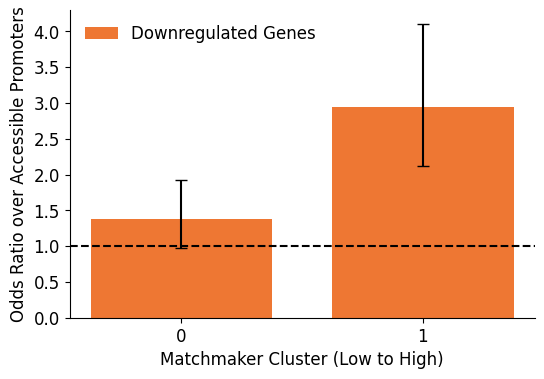

In [23]:

results = get_odds(genes_to_mms, atac_to_mms, ([0, 1], [2, 3]), 
                   test_title='Downregulated Genes',)

fig = plot_odds(results, 2, 'Downregulated Genes', 'Accessible Promoters')
plt.show()

In [24]:
genes_to_mms

,IKZF1_P3_D1,IKZF1_P2_D1,DMSO_P2_D2,DMSO_P3_D1,AAVS1_P3_D1,AAVS1_C2_G1,IKZF1_P3_D2,STAG2_C3_G2,STAG2_C2_G2,AAVS1_P3_D2,...,transcription_start_site,baseMean,log2FoldChange,lfcSE,pvalue,padj,mm_quant,dist,triangle_fc,mm_peak
ENSG00000004777,6.622773,2.328846,2.852778,5.045507,2.708847,5.853810,4.131376,4.544420,4.489039,8.638200,...,35788822,145.831851,-1.879955,0.403681,1.240481e-03,2.691288e-02,2.0,51496.0,0.878124,35737326.0
ENSG00000005249,89.569566,131.449318,117.057289,83.873630,83.680819,122.989417,95.945692,128.345296,115.703313,89.796508,...,107161811,4101.496631,-1.162331,0.172868,4.639476e-08,6.391862e-06,0.0,11451.5,1.015972,107150359.5
ENSG00000022567,4.267328,7.311688,8.763625,4.809798,4.987550,7.070742,4.958639,8.076499,7.418755,8.107498,...,141228574,224.985976,-1.328326,0.277558,2.391121e-04,8.197491e-03,2.0,10466.5,0.946136,141239040.5
ENSG00000030582,77.447417,86.532625,49.239847,58.923267,47.743502,65.391251,94.309908,71.882590,57.687871,54.526293,...,44353106,1205.481581,-1.101217,0.205407,2.708384e-05,1.500420e-03,0.0,21890.5,1.158876,44331215.5
ENSG00000049323,38.231314,25.080124,31.944292,35.969398,22.282336,32.798322,24.941675,38.308534,32.105766,41.303762,...,33399363,1444.545998,-1.532200,0.188102,1.835151e-11,7.642455e-09,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000284946,1.373394,2.266291,2.276553,2.025019,3.909446,6.275881,2.157843,3.612364,3.132712,5.457557,...,91022566,220.450961,-3.280911,0.601873,5.301728e-04,1.469214e-02,2.0,17869.0,0.930968,91004697.0
ENSG00000291139,3.281279,2.857942,3.853648,3.106121,2.215340,4.816262,1.589601,2.590265,3.238100,7.220911,...,103280984,132.039660,-2.450261,0.472445,1.065439e-05,7.109009e-04,3.0,69122.0,1.041752,103350106.0
ENSG00000291159,2.760568,2.456785,2.197428,2.785128,2.504926,2.092659,2.533918,1.583334,2.061478,5.746062,...,84647478,128.743177,-1.455143,0.318678,1.962140e-03,3.681418e-02,2.0,22179.0,1.122840,84625299.0
ENSG00000291250,0.975353,1.345769,1.272764,0.485941,5.268037,9.544152,1.989496,9.143160,5.315397,0.374917,...,31119129,68.763558,-1.572251,0.408660,2.353099e-03,4.154734e-02,NaN,NaN,NaN,NaN


In [25]:
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v3/fig5/"
os.mkdir(savedir)

FileExistsError: [Errno 17] File exists: '/mnt/md0/varshini/Analysis/Blood/figs_v3/fig5/'

In [26]:
genes_to_mms['NIPBL_avg'] = genes_to_mms[['NIPBL_C2_G1', 'NIPBL_C3_G1']].mean(axis=1)
genes_to_mms['AAVS1_avg'] = genes_to_mms[['AAVS1_C2_G1', 'AAVS1_C3_G1']].mean(axis=1)
genes_to_mms['Log2FC'] = np.log2(genes_to_mms['NIPBL_avg']/genes_to_mms['AAVS1_avg'])

In [27]:
genes_to_mms.groupby('mm_quant').agg('size')

mm_quant
0.0    18
1.0    42
2.0    44
3.0    36
dtype: int64

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


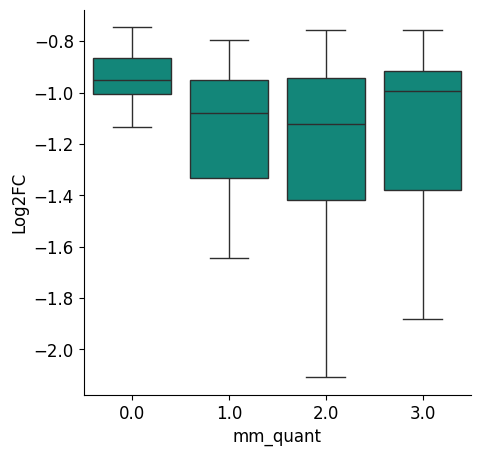

In [99]:
plt.figure(figsize=(5,5))
sns.boxplot(genes_to_mms, x='mm_quant', y='Log2FC', showfliers=False, color="#009988")
#plt.ylim([-2.5, -0.4])
plt.savefig(os.path.join(savedir, "boxplot_txn_mms_nipbl.svg"))

In [953]:
loci = [
    f"chr{c}:{int(t)-200_000}-{int(t)+200_000}"
    for c, t in genes_to_mms_thresh.sort_values(by='baseMean', ascending=False)[
        ['chromosome_name', 'transcription_start_site']
    ].itertuples(index=False, name=None)
]
genes_to_mms_thresh.sort_values(by='baseMean', ascending=False)[['chromosome_name', 'transcription_start_site', 'external_gene_name']][:55]print()

SyntaxError: invalid syntax (3743274255.py, line 7)

In [511]:
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v2"

In [512]:
genes_to_mms = assign_proms_to_mm(mm_df, tpm_df, 0, dist)

In [513]:


tbl = [[len(genes_to_mms_thresh), len(atac_to_mms_notDEG)],
       [len(genes_to_mms) - len(genes_to_mms_thresh), len(atac_to_mms) - len(atac_to_mms_notDEG)]]

#tbl = [[len(genes_to_mms_01), len(atac_to_mms_not23)],
#       [660 - len(genes_to_mms_01), len(atac_proms) - len(atac_to_mms_not23)]]

fisher_exact(tbl)
#odds_ratio(tbl).confidence_interval(confidence_level=0.95)

SignificanceResult(statistic=3.729107165423986, pvalue=8.427599510329902e-15)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='mm_quant', ylabel='triangle_fc'>

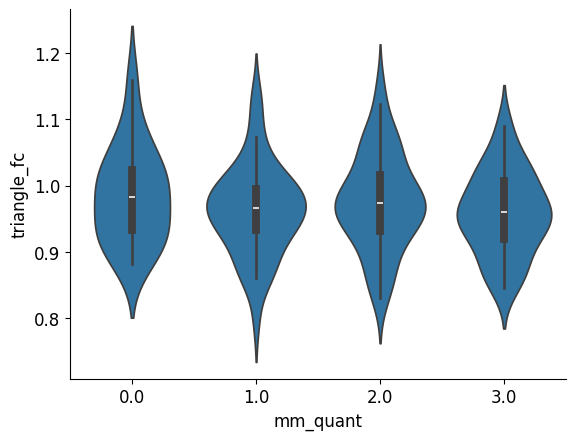

In [514]:
sns.violinplot(genes_to_mms, x='mm_quant', y='triangle_fc')


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='mm_quant', ylabel='triangle_fc'>

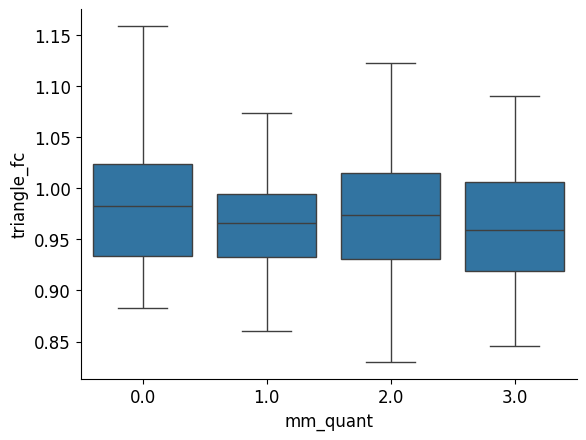

In [515]:
sns.boxplot(genes_to_mms, x='mm_quant', y='triangle_fc', showfliers=False)

In [516]:
genes_to_mms.sort_values(by='triangle_fc')

,IKZF1_P3_D1,IKZF1_P2_D1,DMSO_P2_D2,DMSO_P3_D1,AAVS1_P3_D1,AAVS1_C2_G1,IKZF1_P3_D2,STAG2_C3_G2,STAG2_C2_G2,AAVS1_P3_D2,...,transcription_start_site,baseMean,log2FoldChange,lfcSE,pvalue,padj,mm_quant,dist,triangle_fc,mm_peak
ENSG00000176208,12.451958,13.053767,11.397781,8.037994,8.830880,12.231600,9.036944,7.746204,9.234018,12.382267,...,30895869,585.262832,-1.550791,0.273884,0.001116,0.024960,1.0,58299.5,0.798817,30837569.5
ENSG00000259291,8.954983,12.696869,10.319754,10.864179,14.510194,19.447172,15.122923,18.117510,20.863813,17.099321,...,90076644,349.984320,-1.260307,0.234669,0.000451,0.013059,2.0,16801.5,0.830107,90059842.5
ENSG00000156453,1.814949,2.146479,0.845849,1.937668,2.940850,4.720983,1.619661,3.573840,3.666148,2.803060,...,141878410,153.931603,-1.365800,0.414985,0.000337,0.010668,3.0,28608.0,0.845904,141849802.0
ENSG00000168502,0.325704,0.189590,0.371893,0.304261,0.263877,0.438734,0.498272,0.376631,0.467736,0.563391,...,8832778,21.556250,-4.057678,0.994718,0.000446,0.012953,2.0,2823.5,0.850050,8835601.5
ENSG00000138604,5.704897,9.084440,9.369773,5.366060,6.534497,11.348836,4.614548,11.082800,10.713475,6.607093,...,69272207,473.372408,-1.107719,0.226906,0.000006,0.000460,2.0,87761.5,0.852343,69359968.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000167034,2.572971,5.090254,3.950048,1.753196,3.678626,4.443068,4.090565,4.368405,4.413910,0.698137,...,23682938,103.882226,-1.378079,0.358878,0.001331,0.028351,NaN,NaN,NaN,NaN
ENSG00000171914,2.063251,1.537286,1.157729,1.449415,2.340230,2.622093,1.736031,1.725452,2.543606,2.664801,...,62844631,219.165177,-1.863968,0.375824,0.000155,0.005873,NaN,NaN,NaN,NaN
ENSG00000229807,82.637584,65.748341,87.121227,92.920225,76.181203,108.097931,71.499325,43.732135,74.372449,136.899651,...,73823914,2079.993661,-2.172288,0.359803,0.000583,0.015722,NaN,NaN,NaN,NaN
ENSG00000235703,0.145322,1.015092,0.379269,1.248941,1.177362,1.998035,1.111589,0.268871,0.898986,1.131175,...,150224580,27.935998,-4.535725,0.666764,0.002275,0.040701,NaN,NaN,NaN,NaN


<BarContainer object of 4 artists>

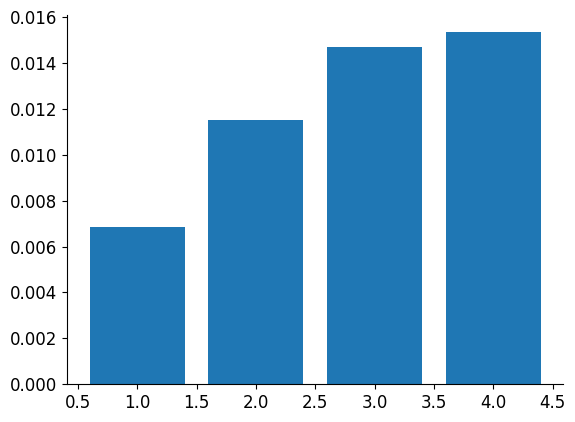

In [517]:
plt.bar(quant_range, genes_to_mms.dropna(subset='dist').groupby('mm_quant').agg('size')/atac_to_mms.dropna(subset='dist').groupby('mm_quant').agg('size'))


In [518]:
tpm_df_all_exp = tpm_df_all[(tpm_df_all[test_phase]>min_exp)|(tpm_df_all[control_phase]>min_exp)]

In [519]:
tpms_to_mms = assign_proms_to_mm(mm_df, tpm_df_all_exp, 0, 100000)

In [520]:
#tpm_in_dist = search_dist_for_proms(mm_df, tpm_df_all_exp, dist=100000)


In [521]:
#genes_in_dist = search_dist_for_proms(mm_df, tpm_df, dist=100000)
frac_comp_mms = mm_df.groupby('quant').agg('size')/len(mm_df)

In [522]:
genes_to_mms.groupby('mm_quant').agg('AAVS1_C3_G1').size()

mm_quant
0.0    18
1.0    42
2.0    44
3.0    36
Name: AAVS1_C3_G1, dtype: int64

In [523]:
genes_to_mms.groupby('mm_quant').agg('NIPBL_C3_G1').mean()

mm_quant
0.0    98.388464
1.0    21.792459
2.0    22.576627
3.0    23.490102
Name: NIPBL_C3_G1, dtype: float64

In [524]:
genes_within_mm = genes_to_mms.dropna(subset='dist').groupby('mm_quant').agg('size')
tpm_within_mm = tpms_to_mms.dropna(subset='dist').groupby('mm_quant').agg('size')

<BarContainer object of 4 artists>

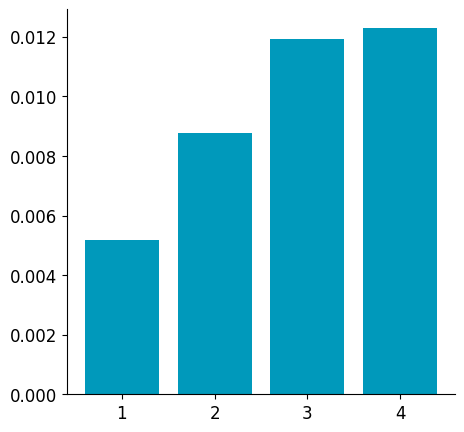

In [525]:
plt.figure(figsize=(5,5))
plt.bar(quant_range, genes_within_mm/tpm_within_mm, color='#0099BB')
#plt.ylim([-2.5, -0.4])
#plt.savefig(os.path.join(savedir, "barplot_txn_mms_nipbl.svg"))

<BarContainer object of 4 artists>

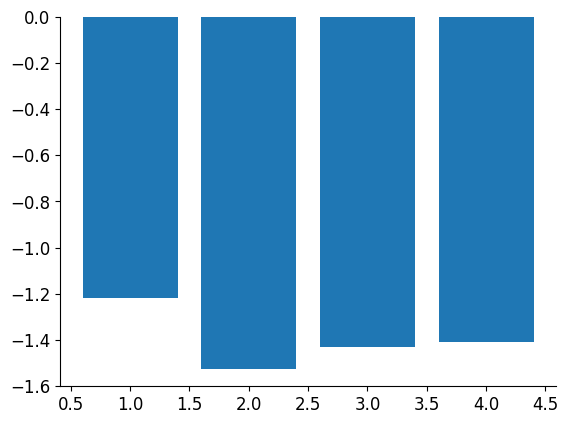

In [526]:
plt.bar(quant_range, genes_to_mms.dropna(subset='dist').groupby('mm_quant')['log2FoldChange'].median())

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


(-3.0, -0.2)

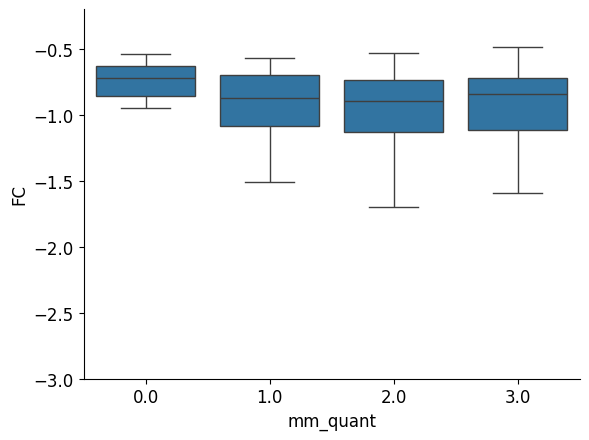

In [527]:
genes_to_mms['FC'] = np.log2(genes_to_mms['NIPBL_C2_G1']/genes_to_mms['AAVS1_C2_G1'])
sns.boxplot(genes_to_mms, x='mm_quant', y='FC', showfliers=False)
plt.ylim([-3, -0.2])

In [528]:
genes_to_mms['FC'] = np.log2(genes_to_mms['NIPBL_C3_G1']/genes_to_mms['AAVS1_C3_G1'])

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


(-3.0, -0.2)

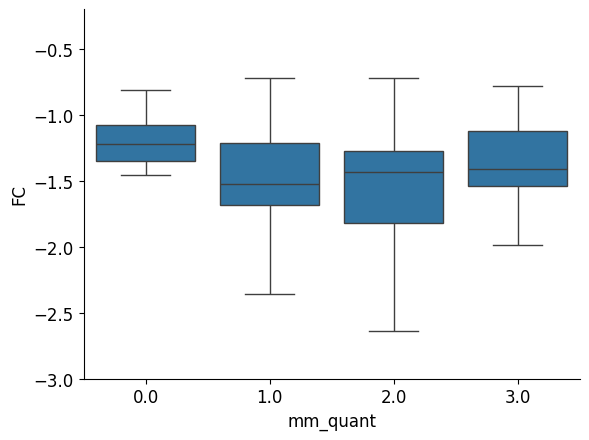

In [529]:
sns.boxplot(genes_to_mms, x='mm_quant', y='FC', showfliers=False)
plt.ylim([-3, -0.2])

In [530]:
genes_to_mms.sort_values(by='log2FoldChange', ascending=True)[['NIPBL_C3_G1','AAVS1_C3_G1', 'log2FoldChange']]

,NIPBL_C3_G1,AAVS1_C3_G1,log2FoldChange
ENSG00000235703,0.051379,1.191719,-4.535725
ENSG00000152953,0.148861,2.715009,-4.188923
ENSG00000168502,0.028788,0.479402,-4.057678
ENSG00000074416,0.205347,2.979910,-3.859132
ENSG00000284946,0.459319,4.464444,-3.280911
...,...,...,...
ENSG00000168906,111.738972,196.051384,-0.811099
ENSG00000117616,114.722633,200.589651,-0.806097
ENSG00000186185,30.052618,51.604019,-0.779993
ENSG00000075702,16.390037,27.082105,-0.724521


In [531]:
os.listdir('/mnt/md0/varshini/Analysis/Blood/figs_v1/')
os.mkdir(savedir)

FileExistsError: [Errno 17] File exists: '/mnt/md0/varshini/Analysis/Blood/figs_v2'

In [532]:
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v1/figure5/"

In [368]:
from scipy.stats import kstest

In [319]:
kstest(genes_to_mms[genes_to_mms['mm_quant']==0]['log2FoldChange'], genes_to_mms[genes_to_mms['mm_quant']==2]['log2FoldChange'])

KstestResult(statistic=0.37453416149068325, pvalue=0.005166483272114177, statistic_location=-0.991688465908687, statistic_sign=-1)

(0.0, 0.9)

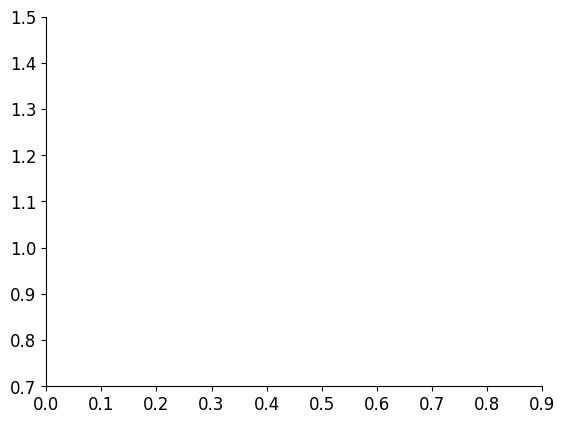

In [215]:
plt.scatter((genes_to_mms['FC']), (genes_to_mms['triangle_fc']), alpha=0.2)
plt.ylim([0.7, 1.5])
plt.xlim([0, 0.9])

In [216]:
genes_to_mms.dropna(subset='dist').groupby('mm_quant')['log2FoldChange'].mean()

mm_quant
0.0   -1.299839
1.0   -1.498842
2.0   -1.654869
3.0   -1.433569
Name: log2FoldChange, dtype: float64

In [217]:
genes_to_mms

,IKZF1_P3_D1,IKZF1_P2_D1,DMSO_P2_D2,DMSO_P3_D1,AAVS1_P3_D1,AAVS1_C2_G1,IKZF1_P3_D2,STAG2_C3_G2,STAG2_C2_G2,AAVS1_P3_D2,...,baseMean,log2FoldChange,lfcSE,pvalue,padj,mm_quant,dist,triangle_fc,mm_peak,FC
ENSG00000004777,6.622773,2.328846,2.852778,5.045507,2.708847,5.853810,4.131376,4.544420,4.489039,8.638200,...,145.831851,-1.879955,0.403681,1.240481e-03,2.691288e-02,2.0,51496.0,0.878124,35737326.0,-1.879955
ENSG00000005249,89.569566,131.449318,117.057289,83.873630,83.680819,122.989417,95.945692,128.345296,115.703313,89.796508,...,4101.496631,-1.162331,0.172868,4.639476e-08,6.391862e-06,0.0,11451.5,1.015972,107150359.5,-1.162331
ENSG00000022567,4.267328,7.311688,8.763625,4.809798,4.987550,7.070742,4.958639,8.076499,7.418755,8.107498,...,224.985976,-1.328326,0.277558,2.391121e-04,8.197491e-03,2.0,10466.5,0.946136,141239040.5,-1.328326
ENSG00000030582,77.447417,86.532625,49.239847,58.923267,47.743502,65.391251,94.309908,71.882590,57.687871,54.526293,...,1205.481581,-1.101217,0.205407,2.708384e-05,1.500420e-03,0.0,21890.5,1.158876,44331215.5,-1.101217
ENSG00000049323,38.231314,25.080124,31.944292,35.969398,22.282336,32.798322,24.941675,38.308534,32.105766,41.303762,...,1444.545998,-1.532200,0.188102,1.835151e-11,7.642455e-09,NaN,NaN,NaN,NaN,-1.532200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000284946,1.373394,2.266291,2.276553,2.025019,3.909446,6.275881,2.157843,3.612364,3.132712,5.457557,...,220.450961,-3.280911,0.601873,5.301728e-04,1.469214e-02,2.0,17869.0,0.930968,91004697.0,-3.280911
ENSG00000291139,3.281279,2.857942,3.853648,3.106121,2.215340,4.816262,1.589601,2.590265,3.238100,7.220911,...,132.039660,-2.450261,0.472445,1.065439e-05,7.109009e-04,3.0,69122.0,1.041752,103350106.0,-2.450261
ENSG00000291159,2.760568,2.456785,2.197428,2.785128,2.504926,2.092659,2.533918,1.583334,2.061478,5.746062,...,128.743177,-1.455143,0.318678,1.962140e-03,3.681418e-02,2.0,22179.0,1.122840,84625299.0,-1.455143
ENSG00000291250,0.975353,1.345769,1.272764,0.485941,5.268037,9.544152,1.989496,9.143160,5.315397,0.374917,...,68.763558,-1.572251,0.408660,2.353099e-03,4.154734e-02,NaN,NaN,NaN,NaN,-1.572251


In [218]:
## split up MMs into how much they were affected ex. <0.9 
# or use crosser fc instead 

## then see the DEGs at each group

## i.e. are there more degs per accessible promoter at changed MMs? reverse of the earlier question

In [219]:
mm_df_dec = mm_df[mm_df['crosser_fc'] < 0.7]

In [220]:
mm_df_dec

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,agg_ss_score_P4,quant,chr_diff,quant_diff,triangle_fc,ss_fc,crosser_fc,ss_crosser_ratio_control,ss_crosser_ratio_test,ratio_fc
13044,chrX,48021514.5,enhancernotpromoternotctcf,0.867108,[1.6623819864957101],['CTCF-Null'],"[(47959500.5, 48025500.5)]",[],[],[],...,0.000000,0,chrX,1.0,0.683579,NaN,0.377245,NaN,NaN,NaN
8786,chr12,62232295.5,enhancernotpromoternotctcf,0.868192,"[2.442997347268712, 2.5702252397988423, 1.8980...","['P-P', 'E-P', 'E-E']","[(62192500.5, 62259500.5), (62211500.5, 622595...","[None, 2.218438677592216]","['E-P', 'E-E']","[(62250500.5, 62259500.5), (62269000.5, 623230...",...,NaN,0,chr12,0.0,0.716402,NaN,0.681901,NaN,NaN,NaN
492,chr1,65437611.0,enhancernotpromoternotctcf,0.667664,[1.7648359168912737],['E-P'],"[(65432500.5, 65526500.5)]",[1.7207683931847677],['E-P'],"[(65481500.5, 65526500.5)]",...,1.195644,0,chr1,0.0,0.767138,0.623223,0.691910,1.803651,2.002437,1.110213
11539,chr18,32117618.5,enhancernotpromoternotctcf,1.082560,"[1.1179061796913645, 1.835227663535898]","['P-Null', 'E-P']","[(32019000.5, 32131000.5), (32093500.5, 321385...","[0.8651551353484923, 1.7567575433160323, 1.574...","['P-CTCF', 'P-CTCF', 'E-P', 'P-P', 'P-Null']","[(32019500.5, 32049500.5), (32019500.5, 320715...",...,7.415605,1,chr18,1.0,0.794918,0.980057,0.472459,0.482284,0.232496,0.482073
4109,chr5,60640807.5,enhancernotpromoternotctcf,1.186525,[1.0226849714103314],['E-Null'],"[(60591000.5, 60643000.5)]",[1.453054369706513],['P-CTCF'],"[(60678500.5, 60699500.5)]",...,1.558824,1,chr5,1.0,0.798493,1.041506,0.447382,1.314677,0.564724,0.429553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12588,chr21,41209242.5,enhancernotpromoternotctcf,1.296401,"[1.5694117018753928, 1.5741904633272084]","['CTCF-Null', 'CTCF-Null']","[(41123000.5, 41279000.5), (41173000.5, 412450...","[1.140931384023125, 1.1413849680016392]","['P-P', 'E-P']","[(41149500.5, 41167500.5), (41171000.5, 412070...",...,2.873145,2,chr21,3.0,1.182641,0.816446,0.491606,0.296285,0.178402,0.602129
6627,chr8,143016234.0,enhancernotpromoternotctcf,1.062710,[1.1530996559813556],['CTCF-CTCF'],"[(142984500.5, 143048500.5)]",[1.0685479293759654],['CTCF-CTCF'],"[(143029500.5, 143048500.5)]",...,1.636684,1,chr8,2.0,1.183725,1.667785,0.378176,1.087749,0.246651,0.226753
1332,chr1,243264118.5,enhancernotpromoternotctcf,1.100809,[1.7473210311987954],['Null-Null'],"[(243261000.5, 243321000.5)]",[1.237208744274457],['Null-Null'],"[(243219000.5, 243249000.5)]",...,1.348395,1,chr1,2.0,1.185102,0.853684,0.524223,1.224561,0.751968,0.614071
9999,chr15,38628335.5,enhancernotpromoternotctcf,1.402588,"[3.9405923320174936, 4.054879196147278]","['P-CTCF', 'P-CTCF']","[(38563500.5, 38685500.5), (38563500.5, 386905...",[],[],[],...,0.000000,2,chr15,3.0,1.276588,NaN,0.540246,NaN,NaN,NaN


In [221]:
mm_df_dec = mm_df[mm_df['crosser_fc']<0.9]

In [222]:
tpm_df_all['log2FoldChange'] = np.log2(tpm_df_all['NIPBL_C2_G1']/tpm_df_all['AAVS1_C2_G1'])

/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [223]:
genes_in_dist = search_dist_for_proms(mm_df, tpm_df, dist=100000)
tpm_in_dist = search_dist_for_proms(mm_df, tpm_df_all, dist=100000)
atac_in_dist = search_dist_for_proms(mm_df, atac_proms_dedup, dist=100000)

/home/varshini/microc_analyses/lib/python3.9/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [224]:
atac_in_dist = search_dist_for_proms(mm_df, atac_proms_dedup, dist=100000)

In [225]:
atac_in_dist.groupby('quant').agg('num_genes').sum()

quant
0    6627
1    9205
2    7439
3    5867
Name: num_genes, dtype: int64

In [226]:
genes_in_dist.groupby('quant').agg('num_genes').sum()

quant
0     80
1    114
2    115
3    122
Name: num_genes, dtype: int64

<BarContainer object of 4 artists>

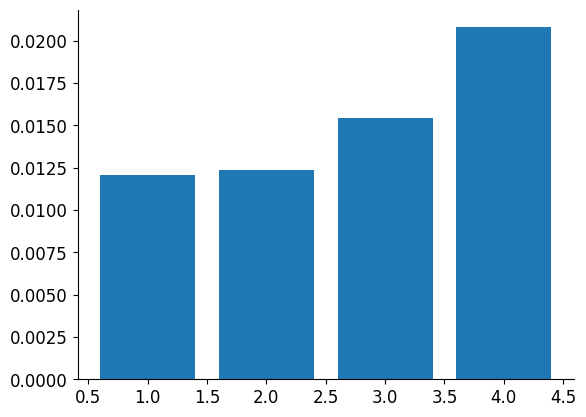

In [227]:
plt.bar(quant_range, genes_in_dist.groupby('quant').agg('num_genes').sum()/atac_in_dist.groupby('quant').agg('num_genes').sum())

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='quant', ylabel='l2fc'>

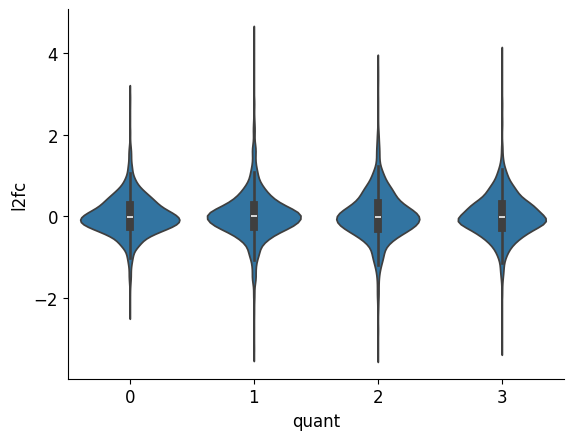

In [228]:
sns.violinplot(tpm_in_dist, x='quant', y='l2fc')

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='quant', ylabel='l2fc'>

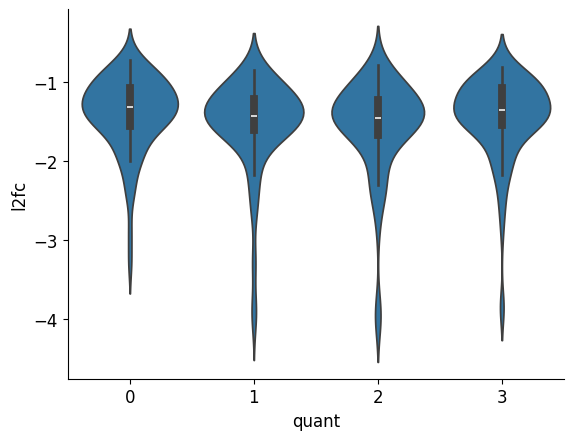

In [229]:
sns.violinplot(genes_in_dist, x='quant', y='l2fc')

In [230]:
tpm_in_dist.groupby('quant').agg('num_genes').sum()

quant
0    18782
1    27847
2    22463
3    16341
Name: num_genes, dtype: int64

####

In [231]:
genes_in_dist[genes_in_dist['num_genes']>0]

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,triangle_fc,ss_fc,crosser_fc,ss_crosser_ratio_control,ss_crosser_ratio_test,ratio_fc,genes,l2fc,min_dist,num_genes
10978,chr17,30837569.5,enhancernotpromoternotctcf,1.186751,[],[],[],"[1.1105226893756404, 1.1692881359469625]","['P-Null', 'E-Null']","[(30807500.5, 30822500.5), (30847000.5, 308890...",...,0.798817,0.989502,NaN,0.000000,0.000000,NaN,[ATAD5],-1.550791,58299.5,1
10343,chr15,90059842.5,enhancernotpromoternotctcf,1.228898,"[2.854868199677358, 2.4625740604977198]","['CTCF-CTCF', 'P-CTCF']","[(89973000.5, 90069000.5), (90002500.5, 900705...","[1.4308541922607079, 1.0824049701495413]","['E-P', 'E-E']","[(90002500.5, 90034500.5), (90144500.5, 901565...",...,0.830107,1.130079,0.778154,2.212221,1.523300,0.688584,[ZNF710-AS1],-1.260307,16801.5,1
6154,chr8,22227723.0,enhancernotpromoternotctcf,0.934757,[],[],[],[1.570504009142672],['P-P'],"[(22144500.5, 22163500.5)]",...,0.833317,1.047028,NaN,0.000000,0.000000,NaN,[HR],-1.945469,96713.0,1
481,chr1,64757349.5,enhancernotpromoternotctcf,1.520163,"[4.7649822983862355, 3.0449377881688493]","['CTCF-CTCF', 'P-CTCF']","[(64687500.5, 64824500.5), (64744500.5, 648235...",[0.9772552258479279],['P-CTCF'],"[(64686500.5, 64744500.5)]",...,0.843249,1.398748,1.169093,5.145477,4.300659,0.835813,[RAVER2],-2.889733,75882.5,1
4442,chr5,141849802.0,enhancernotpromoternotctcf,1.434918,[3.181383072142406],['P-CTCF'],"[(141813500.5, 141878500.5)]",[],[],[],...,0.845904,NaN,0.876176,NaN,NaN,NaN,[PCDH1],-1.3658,28608.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2965,chr3,127860486.5,enhancernotpromoternotctcf,1.123502,[2.80811198359045],['E-Null'],"[(127855500.5, 127959500.5)]",[2.7156490277529213],['E-E'],"[(127862500.5, 127955500.5)]",...,1.138438,1.188175,1.220475,1.175797,1.207761,1.027185,[MGLL],-3.859132,37971.5,1
1195,chr1,220044923.0,enhancernotpromoternotctcf,1.080347,[],[],[],[1.8955667573850923],['CTCF-Null'],"[(219992500.5, 220032500.5)]",...,1.145151,0.830481,NaN,0.000000,0.000000,NaN,[EPRS1],-0.991688,1582.0,1
11085,chr17,44331215.5,enhancernotpromoternotctcf,0.531333,[],[],[],"[4.989284307539524, 3.7020449403368207, 5.6902...","['E-P', 'E-P', 'P-P', 'E-P', 'E-P', 'E-P']","[(44247500.5, 44326500.5), (44267500.5, 442885...",...,1.158876,0.817679,NaN,0.000000,0.000000,NaN,"[GRN, RUNDC3A, RUNDC3A-AS1]",-1.411819,13345.5,3
3281,chr3,183210781.0,enhancernotpromoternotctcf,1.130540,[1.671211967699179],['P-CTCF'],"[(183187500.5, 183253500.5)]",[2.0022449743621893],['CTCF-CTCF'],"[(183123500.5, 183180500.5)]",...,1.198439,0.826438,1.176586,0.762397,1.085412,1.423683,[B3GNT5],-1.522901,62604.0,1


<Axes: xlabel='num_genes', ylabel='Count'>

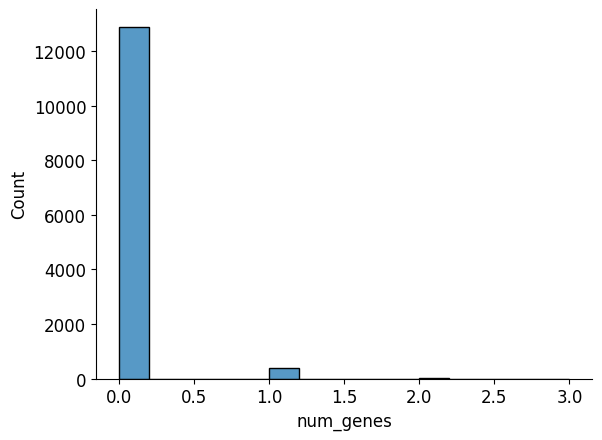

In [232]:
sns.histplot(genes_in_dist['num_genes'])

In [233]:
min_exp = 10

tpm_df_all = pd.read_csv('/mnt/md0/varshini/Analysis/Blood/GeneExp/rnaseq_tpm_annotated.tsv', sep='\t', index_col=0)
tpm_df_all['chr'] = tpm_df_all['chromosome_name'].apply(lambda x: f"chr{x}")
tpm_df_all['transcription_start_site'] = tpm_df_all.apply(
    lambda row: row['transcript_start'] if row['strand'] == '+' else row['transcript_end'],
    axis=1
)


tpm_df_all['AAVS1_avg'] = tpm_df_all[['AAVS1_C3_G1', 'AAVS1_C2_G1']].mean(axis=1)
tpm_df_all['NIPBL_avg'] = tpm_df_all[['NIPBL_C3_G1', 'NIPBL_C2_G1']].mean(axis=1)
tpm_df_all['FC_avg'] = np.log2(tpm_df_all['NIPBL_avg'].divide(tpm_df_all['AAVS1_avg']))
tpm_df_all['FC_C2'] = np.log2(tpm_df_all['NIPBL_C2_G1'].divide(tpm_df_all['AAVS1_C2_G1']))
tpm_df_all['FC_C3'] = np.log2(tpm_df_all['NIPBL_C3_G1'].divide(tpm_df_all['AAVS1_C3_G1']))
tpm_df_expr = tpm_df_all[(tpm_df_all['AAVS1_avg']>min_exp)|(tpm_df_all['NIPBL_avg']>min_exp)]

tpms_expr = tpm_df_expr[~tpm_df_expr.replace([np.inf, -np.inf], np.nan)['FC_C3'].isna()]
tpms_expr['log2FoldChange'] = tpm_df_expr['FC_C3']

/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [234]:
tpms_expr_dec = tpms_expr[tpms_expr['FC_avg']<-0.5]

In [235]:
genes_of_interest=pd.read_csv('/mnt/md0/varshini/Analysis/Blood/GeneExp/NIPBL_AAVS1_down.txt', sep='\t', index_col=0)
tpm_df_genes = tpm_df_all.merge(genes_of_interest, how='inner', left_index=True, right_index=True)

In [236]:
tpm_df_genes

,IKZF1_P3_D1,IKZF1_P2_D1,DMSO_P2_D2,DMSO_P3_D1,AAVS1_P3_D1,AAVS1_C2_G1,IKZF1_P3_D2,STAG2_C3_G2,STAG2_C2_G2,AAVS1_P3_D2,...,FC_avg,FC_C2,FC_C3,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,symbol
ENSG00000005249,89.569566,131.449318,117.057289,83.873630,83.680819,122.989417,95.945692,128.345296,115.703313,89.796508,...,-1.015424,-0.845564,-1.162331,2851.134583,-0.829864,0.161512,-5.138081,2.775587e-07,0.000080,PRKAR2B
ENSG00000006459,22.304295,10.371233,10.322091,24.409873,25.547008,24.754520,20.758427,20.050990,23.063718,26.263680,...,-0.637005,-0.351798,-1.012886,1269.135861,-0.489743,0.150899,-3.245502,1.172437e-03,0.037293,KDM7A
ENSG00000012963,31.451816,60.319161,47.157000,27.590413,36.927975,54.584882,43.662725,64.549001,55.433481,37.947781,...,-0.787830,-0.427713,-1.154794,1161.013069,-0.611916,0.195026,-3.137609,1.703321e-03,0.046836,UBR7
ENSG00000022567,4.267328,7.311688,8.763625,4.809798,4.987550,7.070742,4.958639,8.076499,7.418755,8.107498,...,-1.105324,-0.865128,-1.328326,175.838722,-0.919670,0.221698,-4.148297,3.349579e-05,0.002990,SLC45A4
ENSG00000030582,77.447417,86.532625,49.239847,58.923267,47.743502,65.391251,94.309908,71.882590,57.687871,54.526293,...,-0.956542,-0.819345,-1.101217,1006.075601,-0.776873,0.213273,-3.642616,2.698812e-04,0.013794,GRN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000259291,8.954983,12.696869,10.319754,10.864179,14.510194,19.447172,15.122923,18.117510,20.863813,17.099321,...,-0.944734,-0.663855,-1.260307,228.662826,-0.774395,0.244182,-3.171384,1.517145e-03,0.043510,ZNF710-AS1
ENSG00000267750,4.910755,2.047525,1.430953,5.807798,6.566568,5.084671,6.904797,2.452270,2.717655,9.923912,...,-1.637896,-1.547855,-1.798527,154.727935,-1.477190,0.342185,-4.316938,1.582089e-05,0.001807,ENSG00000267750
ENSG00000275713,23.625206,11.112789,12.611938,15.248228,12.180340,18.356109,27.928308,15.298753,12.100037,16.717885,...,-1.478674,-1.653744,-1.274170,49.536221,-1.296313,0.385092,-3.366242,7.619993e-04,0.028079,H2BC9
ENSG00000284946,1.373394,2.266291,2.276553,2.025019,3.909446,6.275881,2.157843,3.612364,3.132712,5.457557,...,-1.794956,-1.251560,-3.280911,149.273336,-1.711331,0.492842,-3.472374,5.158778e-04,0.021370,ENSG00000284946


In [237]:
# load clustered MMs from og. data
dist = 100000
diff_thresh = 10000

nametag = 'enhancernotpromoternotctcf'
mm = f"/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/nipbl_{nametag}_{dist//1000}kb_merge{diff_thresh/1000}kb_clus.bed"
mm_df = pd.read_csv(mm, sep="\t")

mm_df = matchmaker_functions.merged_attrs(mm_df, test_phase='P4', control_phase='P3')
mm_df['quant_diff'] = mm_df['quant_diff'].clip(upper=3)
mm_df['quant'] = mm_df['quant'].clip(upper=3)
quant_range = np.sort(mm_df['quant'].unique() + 1)

mm_df_change = mm_df.copy()
mm_df_change = mm_df[mm_df['quant_diff']>1] # legit MMs only
mm_df_change['quant'] = pd.qcut(mm_df_change['triangle_fc'], 2, labels=False)

In [238]:
mm_df_change

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,agg_ss_score_P4,quant,chr_diff,quant_diff,triangle_fc,ss_fc,crosser_fc,ss_crosser_ratio_control,ss_crosser_ratio_test,ratio_fc
9191,chr13,25753964.0,enhancernotpromoternotctcf,1.286740,[],[],[],[],[],[],...,0.000000,0,chr13,2.0,0.677355,NaN,NaN,NaN,NaN,NaN
744,chr1,147599967.0,enhancernotpromoternotctcf,1.057915,[],[],[],[],[],[],...,0.000000,0,chr1,2.0,0.732553,NaN,NaN,NaN,NaN,NaN
5815,chr7,93006975.5,enhancernotpromoternotctcf,1.257317,[],[],[],[],[],[],...,0.000000,0,chr7,2.0,0.733178,NaN,NaN,NaN,NaN,NaN
776,chr1,153059875.0,enhancernotpromoternotctcf,1.022976,[],[],[],[1.1197548809636648],['P-P'],"[(153071500.5, 153094500.5)]",...,0.691366,0,chr1,2.0,0.739150,0.457528,NaN,0.0,0.0,NaN
5814,chr7,92995077.5,enhancernotpromoternotctcf,1.329788,[],[],[],[],[],[],...,0.000000,0,chr7,3.0,0.750858,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,chr1,3170988.0,enhancernotpromoternotctcf,1.179480,[],[],[],[],[],[],...,0.000000,1,chr1,2.0,1.317245,NaN,NaN,NaN,NaN,NaN
40,chr1,8122315.5,enhancernotpromoternotctcf,1.031909,[],[],[],[],[],[],...,0.000000,1,chr1,2.0,1.320872,NaN,NaN,NaN,NaN,NaN
1369,chr2,1509726.5,enhancernotpromoternotctcf,1.047878,[],[],[],[],[],[],...,0.000000,1,chr2,2.0,1.324494,NaN,NaN,NaN,NaN,NaN
6269,chr8,49131448.0,enhancernotpromoternotctcf,1.171529,[1.4981533081141511],['E-Null'],"[(49111000.5, 49227000.5)]",[],[],[],...,0.000000,1,chr8,2.0,1.332942,NaN,0.419278,NaN,NaN,NaN


outdir = f'/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/match_quantiles/quantiles_NIPBL'
for quant in mm_df_change['quant'].unique():
    curr_peaks = pd.DataFrame()
    peaks_sub = mm_df_change[mm_df_change['quant']==quant]
    
    curr_peaks['chr'] = peaks_sub['chr']
    curr_peaks['start'] = (peaks_sub['coord']-100).astype(int)
    curr_peaks['end'] = (peaks_sub['coord']+100).astype(int)
    curr_peaks.sort_values(by=['chr','start','end'], inplace=True)
    
    print(curr_peaks)
    curr_peaks.to_csv(os.path.join(outdir, f"quant{quant}_{dist//1000}kb_merge{diff_thresh/1000}kb_clus_ins.bed"), header=False, index=False, sep='\t')

In [239]:
mm_df_change.groupby('quant').agg('triangle_fc').min()

quant
0    0.677355
1    0.989627
Name: triangle_fc, dtype: float64

In [240]:
tpms_in_dist = search_dist_for_proms(mm_df_change, tpms_expr_dec, dist=50000)
genes_in_dist = search_dist_for_proms(mm_df_change, tpm_df_genes, dist=50000)

In [241]:
from scipy.stats import mannwhitneyu

In [242]:
mm_dec_tpm = tpms_in_dist[tpms_in_dist['quant']==0]['l2fc'].replace([np.inf, -np.inf], np.nan).dropna().values
mm_inc_tpm = tpms_in_dist[tpms_in_dist['quant']==1]['l2fc'].replace([np.inf, -np.inf], np.nan).dropna().values

/tmp/ipykernel_3158625/3146977878.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mm_dec_tpm = tpms_in_dist[tpms_in_dist['quant']==0]['l2fc'].replace([np.inf, -np.inf], np.nan).dropna().values
/tmp/ipykernel_3158625/3146977878.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mm_inc_tpm = tpms_in_dist[tpms_in_dist['quant']==1]['l2fc'].replace([np.inf, -np.inf], np.nan).dropna().values


(array([0.0678419 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.0678419 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.27136759,
        0.33920949, 0.1356838 , 0.61057709, 0.33920949, 0.33920949,
        0.54273519, 0.67841899, 0.54273519, 0.67841899, 1.62820557,
        1.69604747, 1.42467987, 1.76388937, 1.56036367, 0.61057709,
        0.54273519, 0.47489329, 0.40705139, 0.61057709, 0.2035257 ]),
 array([-3.60787511, -3.54350762, -3.47914014, -3.41477266, -3.35040518,
        -3.28603769, -3.22167021, -3.15730273, -3.09293525, -3.02856776,
        -2.96420028, -2.8998328 , -2.83546532, -2.77109783, -2.70673035,
        -2.64236287, -2.57799539, -2.5136279 , -2.44926042, -2.38489294,
        -2.32052546, -2.25

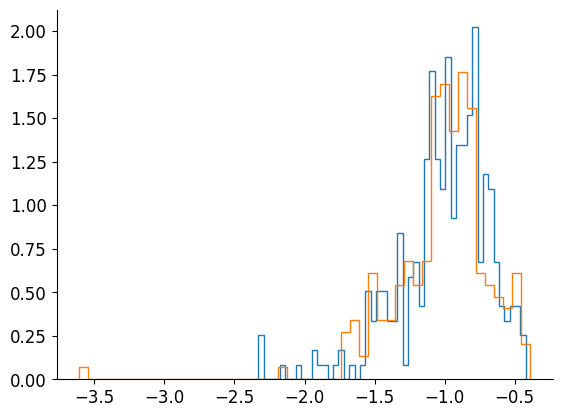

In [243]:
plt.figure()
plt.hist(mm_dec_tpm, histtype='step', bins=50, density=True)
plt.hist(mm_inc_tpm, histtype='step', bins=50,  density=True)

In [244]:
mannwhitneyu(mm_dec_tpm, mm_inc_tpm)

MannwhitneyuResult(statistic=36565.5, pvalue=0.5938636801388764)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='quant', ylabel='l2fc'>

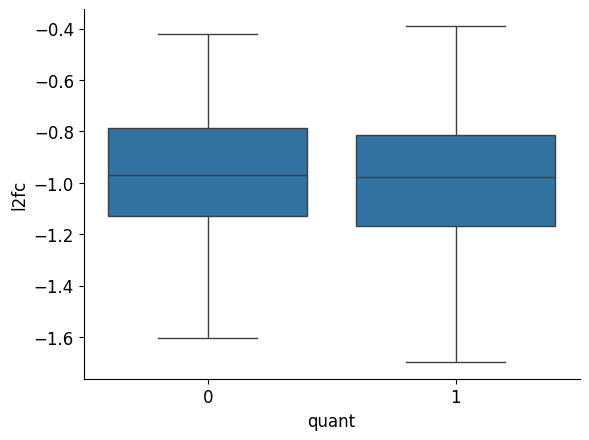

In [245]:
sns.boxplot(tpms_in_dist, x='quant', y='l2fc', showfliers=False)


In [246]:
mm_df_change

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,agg_ss_score_P4,quant,chr_diff,quant_diff,triangle_fc,ss_fc,crosser_fc,ss_crosser_ratio_control,ss_crosser_ratio_test,ratio_fc
9191,chr13,25753964.0,enhancernotpromoternotctcf,1.286740,[],[],[],[],[],[],...,0.000000,0,chr13,2.0,0.677355,NaN,NaN,NaN,NaN,NaN
744,chr1,147599967.0,enhancernotpromoternotctcf,1.057915,[],[],[],[],[],[],...,0.000000,0,chr1,2.0,0.732553,NaN,NaN,NaN,NaN,NaN
5815,chr7,93006975.5,enhancernotpromoternotctcf,1.257317,[],[],[],[],[],[],...,0.000000,0,chr7,2.0,0.733178,NaN,NaN,NaN,NaN,NaN
776,chr1,153059875.0,enhancernotpromoternotctcf,1.022976,[],[],[],[1.1197548809636648],['P-P'],"[(153071500.5, 153094500.5)]",...,0.691366,0,chr1,2.0,0.739150,0.457528,NaN,0.0,0.0,NaN
5814,chr7,92995077.5,enhancernotpromoternotctcf,1.329788,[],[],[],[],[],[],...,0.000000,0,chr7,3.0,0.750858,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,chr1,3170988.0,enhancernotpromoternotctcf,1.179480,[],[],[],[],[],[],...,0.000000,1,chr1,2.0,1.317245,NaN,NaN,NaN,NaN,NaN
40,chr1,8122315.5,enhancernotpromoternotctcf,1.031909,[],[],[],[],[],[],...,0.000000,1,chr1,2.0,1.320872,NaN,NaN,NaN,NaN,NaN
1369,chr2,1509726.5,enhancernotpromoternotctcf,1.047878,[],[],[],[],[],[],...,0.000000,1,chr2,2.0,1.324494,NaN,NaN,NaN,NaN,NaN
6269,chr8,49131448.0,enhancernotpromoternotctcf,1.171529,[1.4981533081141511],['E-Null'],"[(49111000.5, 49227000.5)]",[],[],[],...,0.000000,1,chr8,2.0,1.332942,NaN,0.419278,NaN,NaN,NaN
